# Spaceship Titanic

## 1. Постановка задачи

Необходимо предсказать, был ли пассажир перенесён в другое измерение.

- Тип задачи: бинарная классификация.
- Целевая переменная: `Transported`.
- Метрика соревнования: Accuracy.

В работе будут выполнены:

1. Исследовательский анализ данных.
2. Создание новых признаков.
3. Сравнение нескольких моделей.
4. Подбор гиперпараметров.
5. Построение ансамбля.
6. Создание submission для Kaggle.

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

## 2. Загрузка данных

In [3]:
train = pd.read_csv("/kaggle/input/competitions/spaceship-titanic/train.csv")
test = pd.read_csv("/kaggle/input/competitions/spaceship-titanic/test.csv")
sample_submission = pd.read_csv(
    "/kaggle/input/competitions/spaceship-titanic/sample_submission.csv"
)

In [4]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (8693, 14)
Test shape: (4277, 13)
Sample submission shape: (4277, 2)


In [5]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [6]:
test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [7]:
sample_submission.head()

,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,False
3,0021_01,False
4,0023_01,False


In [8]:
print("Train columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

Train columns:
['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name', 'Transported']

Test columns:
['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name']


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [10]:
train_features = set(train.columns) - {"Transported"}
test_features = set(test.columns)

print("Признаки только в train:", train_features - test_features)
print("Признаки только в test:", test_features - train_features)

assert len(test) == len(sample_submission)
assert test["PassengerId"].equals(sample_submission["PassengerId"])

print("\nTest и sample_submission согласованы")

Признаки только в train: set()
Признаки только в test: set()

Test и sample_submission согласованы


## 3. Анализ целевой переменной

In [11]:
target_counts = train["Transported"].value_counts()
target_share = train["Transported"].value_counts(normalize=True)

print(target_counts)
print()
print(target_share)

Transported
True     4378
False    4315
Name: count, dtype: int64

Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64


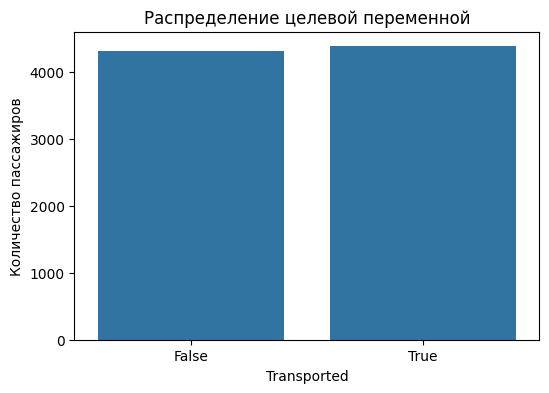

In [12]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=train,
    x="Transported"
)

plt.title("Распределение целевой переменной")
plt.xlabel("Transported")
plt.ylabel("Количество пассажиров")
plt.show()

### Вывод

Целевая переменная практически сбалансирована:

- класс `True` составляет примерно 50,36%;
- класс `False` составляет примерно 49,64%.

Сильного дисбаланса классов нет. Поэтому основной метрикой используется
Accuracy, совпадающая с метрикой соревнования. Oversampling и undersampling
на данном этапе не требуются.

## 4. Анализ пропусков

In [13]:
missing_values = pd.DataFrame({
    "missing_count": train.isna().sum(),
    "missing_percent": train.isna().mean() * 100
})

missing_values = missing_values.sort_values(
    "missing_percent",
    ascending=False
)

missing_values

,missing_count,missing_percent
CryoSleep,217,2.496261
ShoppingMall,208,2.392730
VIP,203,2.335212
HomePlanet,201,2.312205
Name,200,2.300702
Cabin,199,2.289198
VRDeck,188,2.162660
Spa,183,2.105142
FoodCourt,183,2.105142
Destination,182,2.093639


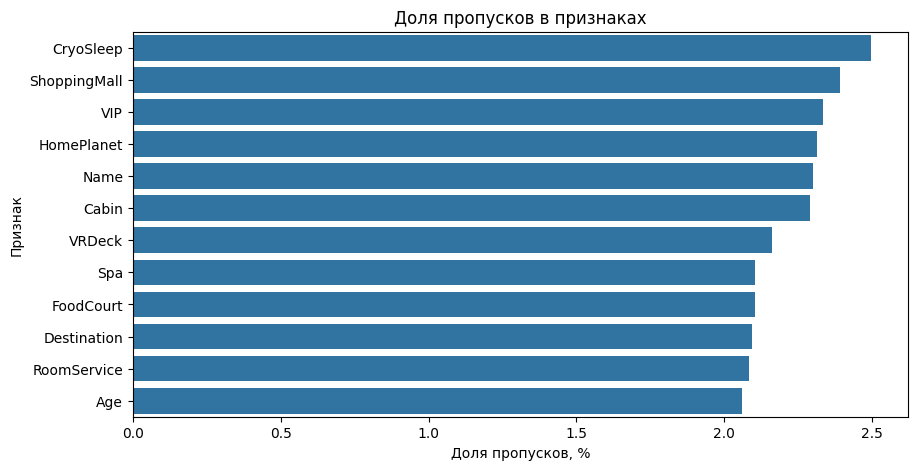

In [14]:
missing_for_plot = missing_values[
    missing_values["missing_count"] > 0
]

plt.figure(figsize=(10, 5))

sns.barplot(
    data=missing_for_plot.reset_index(),
    x="missing_percent",
    y="index"
)

plt.title("Доля пропусков в признаках")
plt.xlabel("Доля пропусков, %")
plt.ylabel("Признак")
plt.show()

### Вывод

Пропуски присутствуют в 12 признаках. Максимальная доля пропусков
составляет около 2,5%, поэтому удалять строки с пропусками нецелесообразно.

В дальнейшем:

- числовые признаки будут заполняться медианой;
- категориальные признаки будут заполняться наиболее частым значением;
- заполнение пропусков будет выполняться внутри ML-пайплайна, чтобы избежать
  утечки данных.

## 5. Проверка дубликатов

In [15]:
print("Полные дубликаты в train:", train.duplicated().sum())

print(
    "Дубликаты PassengerId в train:",
    train["PassengerId"].duplicated().sum()
)

print(
    "Дубликаты PassengerId в test:",
    test["PassengerId"].duplicated().sum()
)

Полные дубликаты в train: 0
Дубликаты PassengerId в train: 0
Дубликаты PassengerId в test: 0


In [16]:
common_ids = set(train["PassengerId"]) & set(test["PassengerId"])

print("Общих PassengerId:", len(common_ids))

Общих PassengerId: 0


### Вывод

Полные дубликаты отсутствуют. Каждый `PassengerId` уникален.
Пересечения пассажиров между обучающей и тестовой выборками нет.
Удаление строк не требуется.

## 6. Анализ числовых признаков

In [17]:
numeric_columns = [
    "Age",
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck"
]

train[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,8514.0,28.827930,14.489021,0.0,19.0,27.0,38.0,79.0
RoomService,8512.0,224.687617,666.717663,0.0,0.0,0.0,47.0,14327.0
FoodCourt,8510.0,458.077203,1611.489240,0.0,0.0,0.0,76.0,29813.0
ShoppingMall,8485.0,173.729169,604.696458,0.0,0.0,0.0,27.0,23492.0
Spa,8510.0,311.138778,1136.705535,0.0,0.0,0.0,59.0,22408.0
VRDeck,8505.0,304.854791,1145.717189,0.0,0.0,0.0,46.0,24133.0


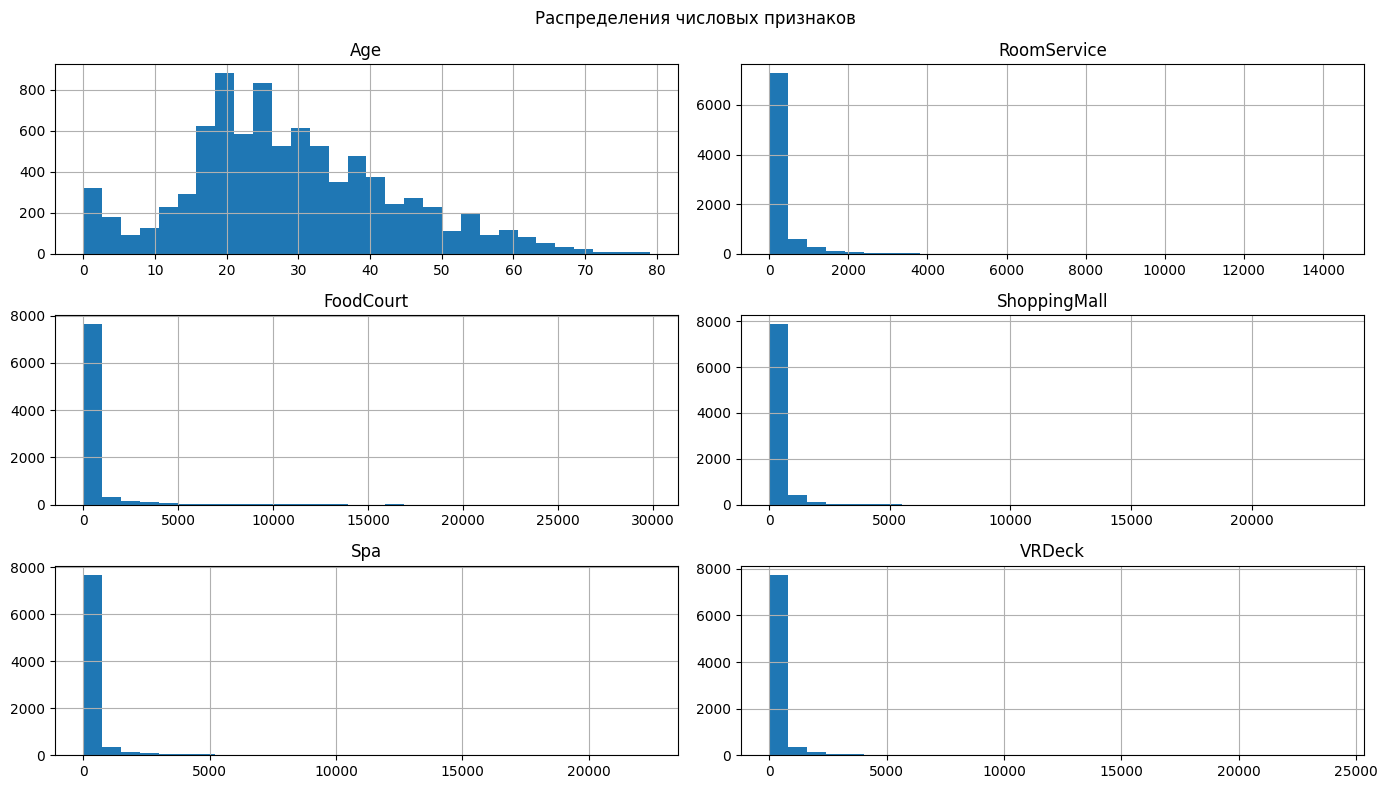

In [18]:
train[numeric_columns].hist(
    figsize=(14, 8),
    bins=30
)

plt.suptitle("Распределения числовых признаков")
plt.tight_layout()
plt.show()

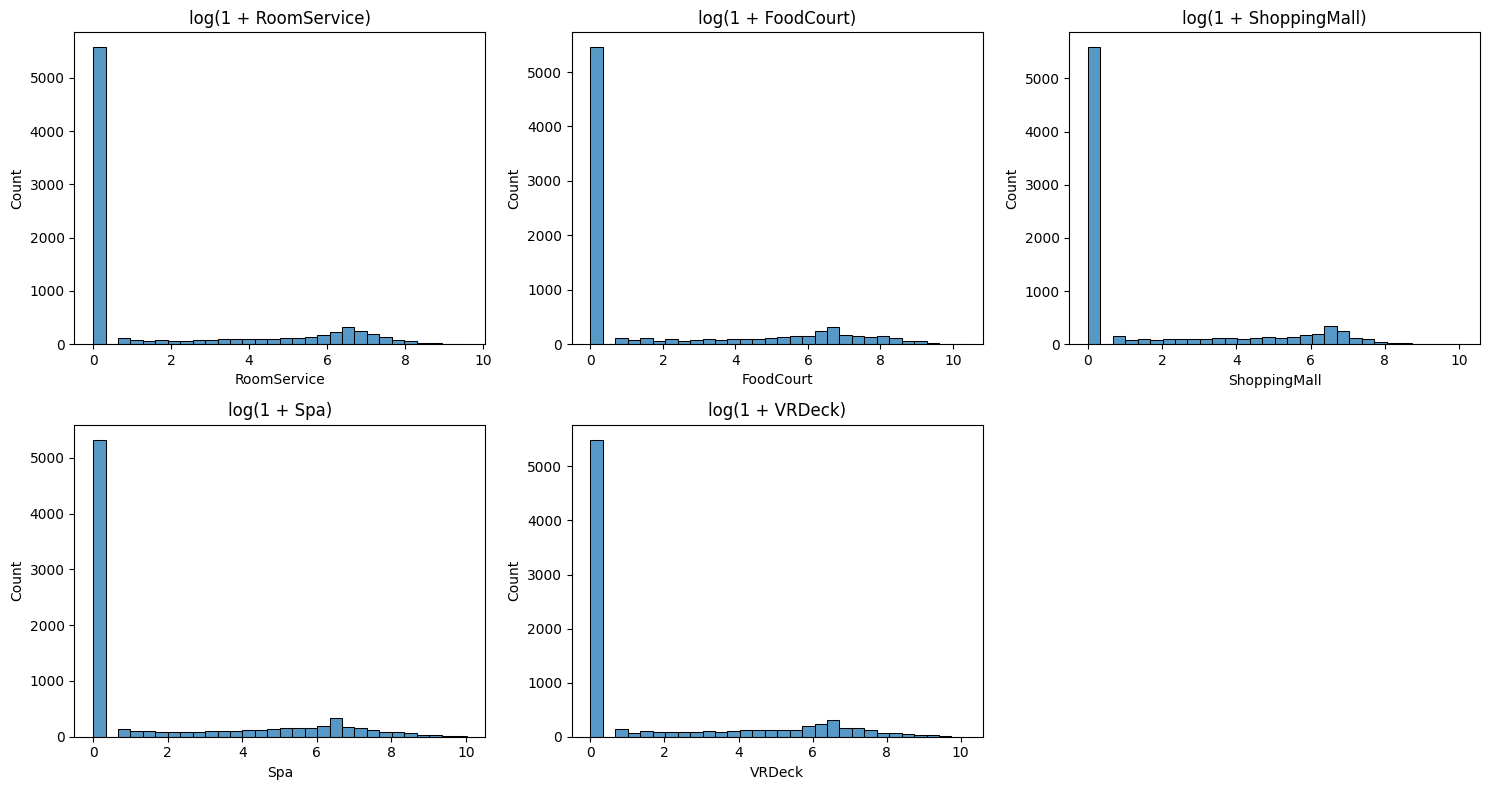

In [19]:
spending_columns = [
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for index, column in enumerate(spending_columns):
    sns.histplot(
        np.log1p(train[column]),
        bins=30,
        ax=axes[index]
    )
    axes[index].set_title(f"log(1 + {column})")

axes[-1].axis("off")

plt.tight_layout()
plt.show()

### Вывод по числовым признакам

Медианный возраст пассажиров составляет 27 лет.

У всех пяти признаков расходов — `RoomService`, `FoodCourt`,
`ShoppingMall`, `Spa` и `VRDeck` — медиана равна нулю. Это означает,
что не менее половины пассажиров не совершали расходов в каждой
из соответствующих категорий.

Средние значения расходов значительно превышают медианы, а максимальные
значения достигают десятков тысяч. Следовательно, распределения расходов
сильно скошены вправо и содержат редкие крупные значения.

В дальнейшем создаются:

- суммарный признак расходов `TotalSpend`;
- бинарный признак `HasSpending`.

## 7. Анализ категориальных признаков

In [20]:
categorical_columns = [
    "HomePlanet",
    "CryoSleep",
    "Destination",
    "VIP"
]

for column in categorical_columns:
    print(f"\nПризнак: {column}")
    print(train[column].value_counts(dropna=False))


Признак: HomePlanet
HomePlanet
Earth     4602
Europa    2131
Mars      1759
NaN        201
Name: count, dtype: int64

Признак: CryoSleep
CryoSleep
False    5439
True     3037
NaN       217
Name: count, dtype: int64

Признак: Destination
Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
NaN               182
Name: count, dtype: int64

Признак: VIP
VIP
False    8291
NaN       203
True      199
Name: count, dtype: int64


In [21]:
for column in categorical_columns:
    target_rate = (
        train.groupby(column, dropna=False)["Transported"]
        .agg(["count", "mean"])
        .sort_values("mean", ascending=False)
    )

    print(f"\nСвязь {column} с Transported:")
    display(target_rate)


Связь HomePlanet с Transported:


,count,mean
HomePlanet,,
Europa,2131,0.658846
Mars,1759,0.523024
NaN,201,0.512438
Earth,4602,0.423946



Связь CryoSleep с Transported:


,count,mean
CryoSleep,,
True,3037,0.817583
NaN,217,0.488479
False,5439,0.328921



Связь Destination с Transported:


,count,mean
Destination,,
55 Cancri e,1800,0.610000
NaN,182,0.505495
PSO J318.5-22,796,0.503769
TRAPPIST-1e,5915,0.471175



Связь VIP с Transported:


,count,mean
VIP,,
NaN,203,0.512315
False,8291,0.506332
True,199,0.381910


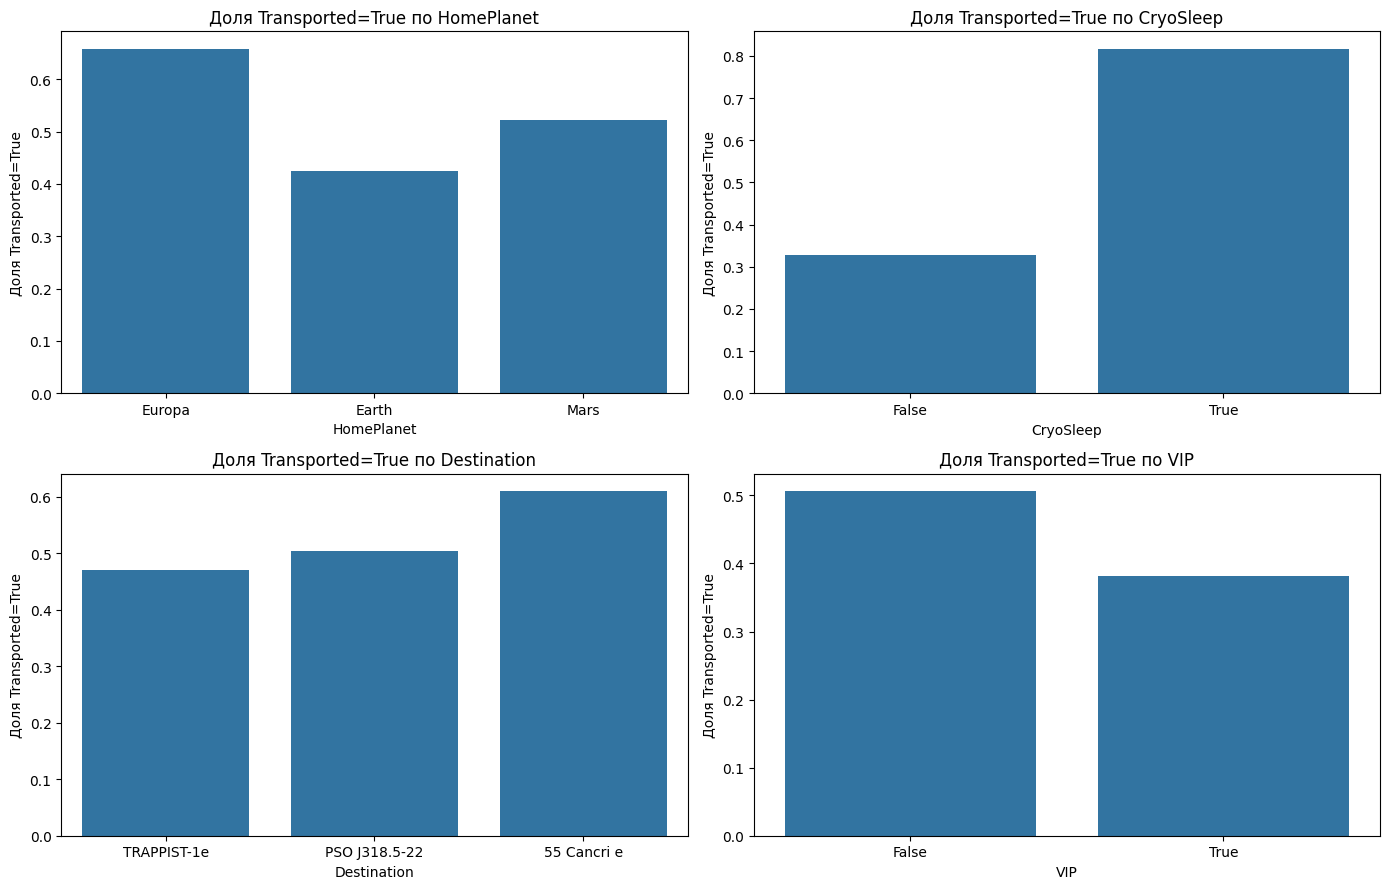

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for index, column in enumerate(categorical_columns):
    sns.barplot(
        data=train,
        x=column,
        y="Transported",
        ax=axes[index],
        errorbar=None
    )

    axes[index].set_title(
        f"Доля Transported=True по {column}"
    )
    axes[index].set_ylabel("Доля Transported=True")

plt.tight_layout()
plt.show()

### Вывод по категориальным признакам

Категориальные признаки имеют разную связь с целевой переменной.
Особенно заметно различие между пассажирами с разными значениями
`CryoSleep`.

Категориальные признаки будут закодированы методом One-Hot Encoding
внутри ML-пайплайна.

## 8. Feature Engineering

In [23]:
def add_features(df):
    df = df.copy()

    source_columns = [
        column for column in df.columns
        if column != "Transported"
    ]
    df["MissingCount"] = df[source_columns].isna().sum(axis=1)

    passenger_parts = df["PassengerId"].str.split("_", expand=True)

    df["GroupId"] = passenger_parts[0]

    df["GroupMemberNumber"] = pd.to_numeric(
        passenger_parts[1],
        errors="coerce"
    )

    group_sizes = df["GroupId"].value_counts()
    df["GroupSize"] = df["GroupId"].map(group_sizes)

    df["IsAlone"] = (df["GroupSize"] == 1).astype(int)

    cabin_parts = df["Cabin"].str.split("/", expand=True)

    df["CabinDeck"] = cabin_parts[0]

    df["CabinNumber"] = pd.to_numeric(
        cabin_parts[1],
        errors="coerce"
    )

    df["CabinSide"] = cabin_parts[2]

    spending_columns = [
        "RoomService",
        "FoodCourt",
        "ShoppingMall",
        "Spa",
        "VRDeck"
    ]

    df["TotalSpend"] = df[spending_columns].sum(
        axis=1,
        min_count=1
    )

    df["HasSpending"] = np.where(
        df["TotalSpend"].isna(),
        np.nan,
        (df["TotalSpend"] > 0).astype(int)
    )

    df["AgeGroup"] = pd.cut(
        df["Age"],
        bins=[-1, 12, 18, 30, 50, np.inf],
        labels=[
            "Child",
            "Teen",
            "Young",
            "Adult",
            "Senior"
        ]
    )

    return df

In [24]:
train_fe = add_features(train)
test_fe = add_features(test)

print("Train после feature engineering:", train_fe.shape)
print("Test после feature engineering:", test_fe.shape)

Train после feature engineering: (8693, 25)
Test после feature engineering: (4277, 24)


In [25]:
new_features = [
    "PassengerId",
    "GroupId",
    "GroupMemberNumber",
    "GroupSize",
    "IsAlone",
    "Cabin",
    "CabinDeck",
    "CabinNumber",
    "CabinSide",
    "TotalSpend",
    "HasSpending",
    "AgeGroup",
    "MissingCount"
]

train_fe[new_features].head(10)

,PassengerId,GroupId,GroupMemberNumber,GroupSize,IsAlone,Cabin,CabinDeck,CabinNumber,CabinSide,TotalSpend,HasSpending,AgeGroup,MissingCount
0,0001_01,0001,1,1,1,B/0/P,B,0.0,P,0.0,0.0,Adult,0
1,0002_01,0002,1,1,1,F/0/S,F,0.0,S,736.0,1.0,Young,0
2,0003_01,0003,1,2,0,A/0/S,A,0.0,S,10383.0,1.0,Senior,0
3,0003_02,0003,2,2,0,A/0/S,A,0.0,S,5176.0,1.0,Adult,0
4,0004_01,0004,1,1,1,F/1/S,F,1.0,S,1091.0,1.0,Teen,0
5,0005_01,0005,1,1,1,F/0/P,F,0.0,P,774.0,1.0,Adult,0
6,0006_01,0006,1,2,0,F/2/S,F,2.0,S,1584.0,1.0,Young,0
7,0006_02,0006,2,2,0,G/0/S,G,0.0,S,0.0,0.0,Young,1
8,0007_01,0007,1,1,1,F/3/S,F,3.0,S,1018.0,1.0,Adult,0
9,0008_01,0008,1,3,0,B/1/P,B,1.0,P,0.0,0.0,Teen,0


In [26]:
print("Распределение размеров групп:")
print(
    train_fe["GroupSize"]
    .value_counts()
    .sort_index()
)

print("\nПутешествует один:")
print(train_fe["IsAlone"].value_counts())

print("\nПалубы:")
print(train_fe["CabinDeck"].value_counts(dropna=False))

print("\nСтороны корабля:")
print(train_fe["CabinSide"].value_counts(dropna=False))

print("\nНаличие расходов:")
print(train_fe["HasSpending"].value_counts(dropna=False))

Распределение размеров групп:
GroupSize
1    4805
2    1682
3    1020
4     412
5     265
6     174
7     231
8     104
Name: count, dtype: int64

Путешествует один:
IsAlone
1    4805
0    3888
Name: count, dtype: int64

Палубы:
CabinDeck
F      2794
G      2559
E       876
B       779
C       747
D       478
A       256
NaN     199
T         5
Name: count, dtype: int64

Стороны корабля:
CabinSide
S      4288
P      4206
NaN     199
Name: count, dtype: int64

Наличие расходов:
HasSpending
1.0    5040
0.0    3653
Name: count, dtype: int64


In [27]:
def show_target_rate(df, column):
    result = (
        df.groupby(
            column,
            dropna=False,
            observed=False
        )["Transported"]
        .agg(["count", "mean"])
        .sort_values("mean", ascending=False)
    )

    result["mean"] = result["mean"].round(4)

    return result

In [28]:
show_target_rate(train_fe, "IsAlone")

,count,mean
IsAlone,,
0,3888,0.5669
1,4805,0.4524


In [29]:
show_target_rate(train_fe, "HasSpending")

,count,mean
HasSpending,,
0.0,3653,0.7865
1.0,5040,0.2986


In [30]:
show_target_rate(train_fe, "CabinSide")

,count,mean
CabinSide,,
S,4288,0.5550
NaN,199,0.5025
P,4206,0.4513


In [31]:
show_target_rate(train_fe, "CabinDeck")

,count,mean
CabinDeck,,
B,779,0.7343
C,747,0.6801
G,2559,0.5162
NaN,199,0.5025
A,256,0.4961
F,2794,0.4399
D,478,0.4331
E,876,0.3573
T,5,0.2000


In [32]:
show_target_rate(train_fe, "AgeGroup")

,count,mean
AgeGroup,,
Child,806,0.6998
Teen,1059,0.5373
NaN,179,0.5028
Senior,737,0.4844
Adult,2674,0.4794
Young,3238,0.4682


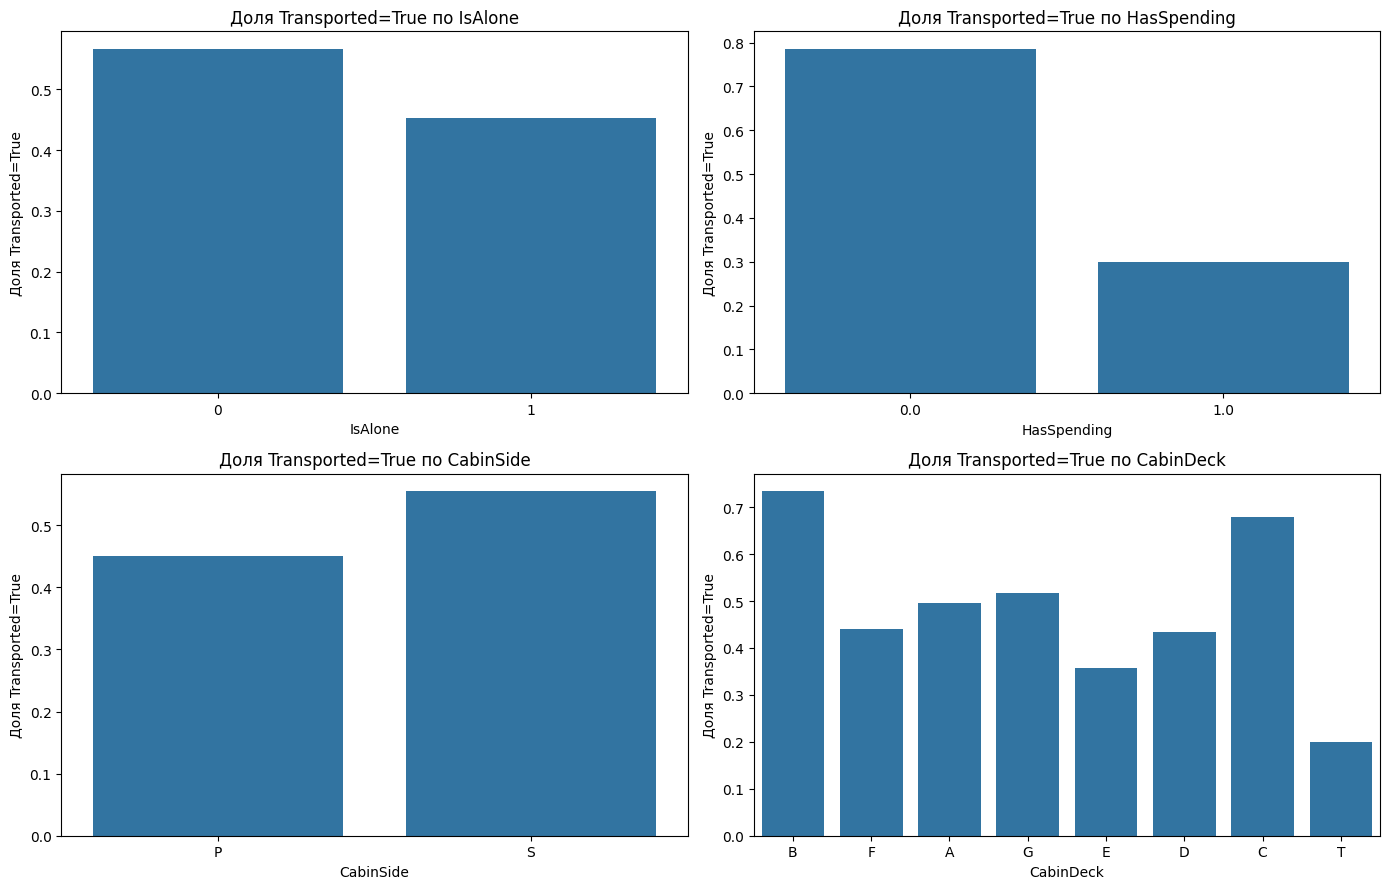

In [33]:
features_to_plot = [
    "IsAlone",
    "HasSpending",
    "CabinSide",
    "CabinDeck"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for index, feature in enumerate(features_to_plot):
    sns.barplot(
        data=train_fe,
        x=feature,
        y="Transported",
        errorbar=None,
        ax=axes[index]
    )

    axes[index].set_title(
        f"Доля Transported=True по {feature}"
    )
    axes[index].set_xlabel(feature)
    axes[index].set_ylabel("Доля Transported=True")

plt.tight_layout()
plt.show()

### Вывод по созданным признакам

Из исходных данных были получены новые характеристики:

- размер группы и факт одиночного путешествия;
- палуба, номер и сторона каюты;
- суммарные расходы и факт наличия расходов;
- возрастная категория;
- количество пропусков в записи пассажира.

Наиболее выраженная зависимость наблюдается у `HasSpending`.
Также полезными выглядят `IsAlone`, `CabinDeck`, `CabinSide`
и `AgeGroup`.

Полезность новых признаков далее проверяется через изменение
Accuracy на кросс-валидации.

## 9. Baseline: Logistic Regression на исходных признаках

Для baseline используются исходные признаки без feature engineering.

Из рассмотрения временно исключаются:

- `PassengerId`;
- `Cabin`;
- `Name`.

Заполнение пропусков, масштабирование и кодирование категорий
выполняются внутри `Pipeline`.

In [34]:
baseline_features = [
    "HomePlanet",
    "CryoSleep",
    "Destination",
    "Age",
    "VIP",
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck"
]

X_baseline = train[baseline_features].copy()
y = train["Transported"].astype(int)

numeric_features = [
    "Age",
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck"
]

categorical_features = [
    "HomePlanet",
    "CryoSleep",
    "Destination",
    "VIP"
]

print("Размер X_baseline:", X_baseline.shape)
print("Размер y:", y.shape)

print("\nПропуски:")
print(X_baseline.isna().sum())

print("\nЧисловые признаки:", numeric_features)
print("Категориальные признаки:", categorical_features)

Размер X_baseline: (8693, 10)
Размер y: (8693,)

Пропуски:
HomePlanet      201
CryoSleep       217
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
dtype: int64

Числовые признаки: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
Категориальные признаки: ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score
)

In [36]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_transformer,
        numeric_features
    ),
    (
        "categorical",
        categorical_transformer,
        categorical_features
    )
])

In [37]:
baseline_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        )
    )
])

In [38]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

baseline_scores = cross_val_score(
    estimator=baseline_model,
    X=X_baseline,
    y=y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("Accuracy по фолдам:")
print(np.round(baseline_scores, 4))

print(
    "\nСредняя Accuracy:",
    round(baseline_scores.mean(), 4)
)

print(
    "Стандартное отклонение:",
    round(baseline_scores.std(), 4)
)

Accuracy по фолдам:
[0.789  0.7752 0.8005 0.79   0.7756]

Средняя Accuracy: 0.786
Стандартное отклонение: 0.0096


### Результат baseline

Для оценки использовалась стратифицированная пятикратная
кросс-валидация с метрикой Accuracy.

В предыдущем запуске были получены:

- средняя Accuracy: `0.7860`;
- стандартное отклонение: `0.0096`.

Фактические значения необходимо сверить с выводом ячейки выше.
Этот результат используется как baseline.

## 10. Logistic Regression после Feature Engineering

Используется та же модель, та же схема кросс-валидации и та же
метрика. Это позволяет отдельно оценить влияние новых признаков.

In [39]:
columns_to_drop = [
    "Transported",
    "PassengerId",
    "GroupId",
    "Cabin",
    "Name"
]

X_fe = train_fe.drop(columns=columns_to_drop).copy()

print("Размер X_fe:", X_fe.shape)
print("Размер y:", y.shape)

print("\nПризнаки после feature engineering:")
print(X_fe.columns.tolist())

Размер X_fe: (8693, 20)
Размер y: (8693,)

Признаки после feature engineering:
['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'MissingCount', 'GroupMemberNumber', 'GroupSize', 'IsAlone', 'CabinDeck', 'CabinNumber', 'CabinSide', 'TotalSpend', 'HasSpending', 'AgeGroup']


In [40]:
numeric_features_fe = (
    X_fe
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_features_fe = (
    X_fe
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

print("Числовые признаки:")
print(numeric_features_fe)

print("\nКатегориальные признаки:")
print(categorical_features_fe)

print(
    "\nОбщее количество признаков:",
    len(numeric_features_fe) + len(categorical_features_fe)
)

Числовые признаки:
['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'MissingCount', 'GroupMemberNumber', 'GroupSize', 'IsAlone', 'CabinNumber', 'TotalSpend', 'HasSpending']

Категориальные признаки:
['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'CabinDeck', 'CabinSide', 'AgeGroup']

Общее количество признаков: 20


In [41]:
numeric_transformer_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_fe = ColumnTransformer([
    (
        "numeric",
        numeric_transformer_fe,
        numeric_features_fe
    ),
    (
        "categorical",
        categorical_transformer_fe,
        categorical_features_fe
    )
])

In [42]:
logreg_fe_model = Pipeline([
    (
        "preprocessor",
        preprocessor_fe
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        )
    )
])

In [43]:
fe_scores = cross_val_score(
    estimator=logreg_fe_model,
    X=X_fe,
    y=y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("Accuracy по фолдам:")
print(np.round(fe_scores, 4))

print(
    "\nСредняя Accuracy:",
    round(fe_scores.mean(), 4)
)

print(
    "Стандартное отклонение:",
    round(fe_scores.std(), 4)
)

Accuracy по фолдам:
[0.7924 0.7838 0.7953 0.7969 0.7854]

Средняя Accuracy: 0.7908
Стандартное отклонение: 0.0053


In [44]:
comparison = pd.DataFrame({
    "Модель": [
        "Logistic Regression: baseline",
        "Logistic Regression: feature engineering"
    ],
    "Средняя Accuracy": [
        baseline_scores.mean(),
        fe_scores.mean()
    ],
    "Стандартное отклонение": [
        baseline_scores.std(),
        fe_scores.std()
    ]
})

comparison[
    ["Средняя Accuracy", "Стандартное отклонение"]
] = comparison[
    ["Средняя Accuracy", "Стандартное отклонение"]
].round(4)

comparison

,Модель,Средняя Accuracy,Стандартное отклонение
0,Logistic Regression: baseline,0.7860,0.0096
1,Logistic Regression: feature engineering,0.7908,0.0053


In [45]:
accuracy_gain = fe_scores.mean() - baseline_scores.mean()

print(
    "Изменение Accuracy после Feature Engineering:",
    round(accuracy_gain, 4)
)

Изменение Accuracy после Feature Engineering: 0.0047


In [46]:
fold_comparison = pd.DataFrame({
    "Фолд": np.arange(1, len(baseline_scores) + 1),
    "Baseline": baseline_scores,
    "Feature Engineering": fe_scores,
    "Изменение": fe_scores - baseline_scores
})

fold_comparison = fold_comparison.round(4)
fold_comparison

,Фолд,Baseline,Feature Engineering,Изменение
0,1,0.7890,0.7924,0.0035
1,2,0.7752,0.7838,0.0086
2,3,0.8005,0.7953,-0.0052
3,4,0.7900,0.7969,0.0069
4,5,0.7756,0.7854,0.0098


In [47]:
print(
    "Feature Engineering улучшил результат на",
    (fold_comparison["Изменение"] > 0).sum(),
    "фолдах из",
    len(fold_comparison)
)

Feature Engineering улучшил результат на 4 фолдах из 5


### Вывод о влиянии Feature Engineering

В предыдущем запуске средняя Accuracy логистической регрессии
увеличилась с `0.7860` до `0.7908`. Абсолютный прирост составил
`0.0047`, или 0,47 процентного пункта.

Feature Engineering улучшил результат на четырёх фолдах из пяти.
Стандартное отклонение снизилось с `0.0096` до `0.0053`, поэтому
результат стал стабильнее.

Прирост небольшой, поскольку `TotalSpend` и `HasSpending` построены
на основе уже используемых признаков расходов. Новые признаки далее
проверяются на нелинейной модели.

## 11. Random Forest

Random Forest способен учитывать нелинейные зависимости и
взаимодействия между признаками.

Для сравнения используется та же пятикратная стратифицированная
кросс-валидация и метрика Accuracy.

In [48]:
numeric_transformer_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_tree = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_tree = ColumnTransformer([
    (
        "numeric",
        numeric_transformer_tree,
        numeric_features_fe
    ),
    (
        "categorical",
        categorical_transformer_tree,
        categorical_features_fe
    )
])

In [49]:
random_forest_model = Pipeline([
    (
        "preprocessor",
        preprocessor_tree
    ),
    (
        "model",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=20,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])

In [50]:
rf_scores = cross_val_score(
    estimator=random_forest_model,
    X=X_fe,
    y=y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("Accuracy Random Forest по фолдам:")
print(np.round(rf_scores, 4))

print(
    "\nСредняя Accuracy:",
    round(rf_scores.mean(), 4)
)

print(
    "Стандартное отклонение:",
    round(rf_scores.std(), 4)
)

Accuracy Random Forest по фолдам:
[0.812  0.797  0.8022 0.8147 0.7906]

Средняя Accuracy: 0.8033
Стандартное отклонение: 0.009


In [51]:
model_comparison = pd.DataFrame({
    "Модель": [
        "Logistic Regression: baseline",
        "Logistic Regression: feature engineering",
        "Random Forest: feature engineering"
    ],
    "Средняя Accuracy": [
        baseline_scores.mean(),
        fe_scores.mean(),
        rf_scores.mean()
    ],
    "Стандартное отклонение": [
        baseline_scores.std(),
        fe_scores.std(),
        rf_scores.std()
    ]
})

model_comparison[
    ["Средняя Accuracy", "Стандартное отклонение"]
] = model_comparison[
    ["Средняя Accuracy", "Стандартное отклонение"]
].round(4)

model_comparison.sort_values(
    "Средняя Accuracy",
    ascending=False
)

,Модель,Средняя Accuracy,Стандартное отклонение
2,Random Forest: feature engineering,0.8033,0.0090
1,Logistic Regression: feature engineering,0.7908,0.0053
0,Logistic Regression: baseline,0.7860,0.0096


## 12. Gradient Boosting

Следующей рассматривается модель градиентного бустинга.

В отличие от Random Forest, где деревья обучаются независимо,
в Gradient Boosting каждое следующее дерево исправляет ошибки
предыдущего ансамбля.

Для корректного сравнения используются:

- те же признаки после Feature Engineering;
- та же пятикратная StratifiedKFold;
- метрика Accuracy;
- обработка пропусков и категорий внутри Pipeline.

In [52]:
from sklearn.ensemble import GradientBoostingClassifier

In [53]:
gradient_boosting_model = Pipeline([
    (
        "preprocessor",
        preprocessor_tree
    ),
    (
        "model",
        GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=5,
            random_state=RANDOM_STATE
        )
    )
])

In [54]:
preprocessor_tree

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['Age', 'RoomService', 'FoodCourt',
                                  'ShoppingMall', 'Spa', 'VRDeck',
                                  'MissingCount', 'GroupMemberNumber',
                                  'GroupSize', 'IsAlone', 'CabinNumber',
                                  'TotalSpend', 'HasSpending']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['HomePlanet', 'CryoSleep', 'Destination',
                                  'VIP', 'CabinDeck', 'CabinSide',
                                  'AgeGroup'])])

In [55]:
gb_scores = cross_val_score(
    estimator=gradient_boosting_model,
    X=X_fe,
    y=y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("Accuracy Gradient Boosting по фолдам:")
print(np.round(gb_scores, 4))

print(
    "\nСредняя Accuracy:",
    round(gb_scores.mean(), 4)
)

print(
    "Стандартное отклонение:",
    round(gb_scores.std(), 4)
)

Accuracy Gradient Boosting по фолдам:
[0.8056 0.8079 0.7941 0.8199 0.8038]

Средняя Accuracy: 0.8063
Стандартное отклонение: 0.0083


In [56]:
model_comparison = pd.DataFrame({
    "Модель": [
        "Logistic Regression: baseline",
        "Logistic Regression: feature engineering",
        "Random Forest: feature engineering",
        "Gradient Boosting: feature engineering"
    ],
    "Средняя Accuracy": [
        baseline_scores.mean(),
        fe_scores.mean(),
        rf_scores.mean(),
        gb_scores.mean()
    ],
    "Стандартное отклонение": [
        baseline_scores.std(),
        fe_scores.std(),
        rf_scores.std(),
        gb_scores.std()
    ]
})

model_comparison[
    ["Средняя Accuracy", "Стандартное отклонение"]
] = model_comparison[
    ["Средняя Accuracy", "Стандартное отклонение"]
].round(4)

model_comparison = model_comparison.sort_values(
    "Средняя Accuracy",
    ascending=False
).reset_index(drop=True)

model_comparison

,Модель,Средняя Accuracy,Стандартное отклонение
0,Gradient Boosting: feature engineering,0.8063,0.0083
1,Random Forest: feature engineering,0.8033,0.0090
2,Logistic Regression: feature engineering,0.7908,0.0053
3,Logistic Regression: baseline,0.7860,0.0096


### Результат Gradient Boosting

Gradient Boosting показал среднюю Accuracy 0.8063
при стандартном отклонении 0.0083.

Модель использует последовательное построение деревьев,
где каждое новое дерево исправляет ошибки предыдущего ансамбля.
Полученный результат будет учтён при выборе моделей
для последующего подбора гиперпараметров и ансамблирования.

## 13. LightGBM

LightGBM - реализация градиентного бустинга над деревьями решений.

Модель сравнивается с предыдущими алгоритмами на тех же данных
после Feature Engineering, с использованием той же пятикратной
стратифицированной кросс-валидации и метрики Accuracy.

Для обработки пропусков и категориальных признаков используется
ранее созданный `preprocessor_tree`.

In [57]:
from lightgbm import LGBMClassifier

In [58]:
lightgbm_model = Pipeline([
    (
        "preprocessor",
        preprocessor_tree
    ),
    (
        "model",
        LGBMClassifier(
            n_estimators=300,
            learning_rate=0.1,
            max_depth=6,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        )
    )
])

In [59]:
lgbm_scores = cross_val_score(
    estimator=lightgbm_model,
    X=X_fe,
    y=y,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print("Accuracy LightGBM по фолдам:")
print(np.round(lgbm_scores, 4))

print(
    "\nСредняя Accuracy:",
    round(lgbm_scores.mean(), 4)
)

print(
    "Стандартное отклонение:",
    round(lgbm_scores.std(), 4)
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy LightGBM по фолдам:
[0.8125 0.8062 0.8016 0.8193 0.8067]

Средняя Accuracy: 0.8093
Стандартное отклонение: 0.0061


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [60]:
model_comparison = pd.DataFrame({
    "Модель": [
        "Logistic Regression: baseline",
        "Logistic Regression: feature engineering",
        "Random Forest: feature engineering",
        "Gradient Boosting: feature engineering",
        "LightGBM: feature engineering"
    ],
    "Средняя Accuracy": [
        baseline_scores.mean(),
        fe_scores.mean(),
        rf_scores.mean(),
        gb_scores.mean(),
        lgbm_scores.mean()
    ],
    "Стандартное отклонение": [
        baseline_scores.std(),
        fe_scores.std(),
        rf_scores.std(),
        gb_scores.std(),
        lgbm_scores.std()
    ]
})

model_comparison[
    ["Средняя Accuracy", "Стандартное отклонение"]
] = model_comparison[
    ["Средняя Accuracy", "Стандартное отклонение"]
].round(4)

model_comparison = model_comparison.sort_values(
    "Средняя Accuracy",
    ascending=False
).reset_index(drop=True)

model_comparison

,Модель,Средняя Accuracy,Стандартное отклонение
0,LightGBM: feature engineering,0.8093,0.0061
1,Gradient Boosting: feature engineering,0.8063,0.0083
2,Random Forest: feature engineering,0.8033,0.0090
3,Logistic Regression: feature engineering,0.7908,0.0053
4,Logistic Regression: baseline,0.7860,0.0096


### Результат LightGBM

LightGBM показал среднюю Accuracy 0.8093 при стандартном
отклонении 0.0061.

После сравнения четырёх разных алгоритмов лучшими моделями
оказались LightGBM и Gradient Boosting. Они будут использоваться на следующем
этапе для подбора гиперпараметров.

## 14. Подбор гиперпараметров LightGBM

LightGBM показал лучший результат среди рассмотренных моделей,
поэтому для него выполняется подбор гиперпараметров.

Для подбора используется `RandomizedSearchCV` с трёхкратной
стратифицированной кросс-валидацией и метрикой Accuracy.

После выбора параметров лучшая модель будет отдельно проверена
на исходной пятикратной кросс-валидации.

Все этапы предварительной обработки остаются внутри Pipeline.

In [61]:
from sklearn.model_selection import RandomizedSearchCV

In [62]:
lightgbm_tune_model = Pipeline([
    (
        "preprocessor",
        preprocessor_tree
    ),
    (
        "model",
        LGBMClassifier(
            random_state=RANDOM_STATE,
            n_jobs=1,
            verbose=-1
        )
    )
])

In [63]:
lgbm_param_distributions = {
    "model__n_estimators": [200, 300, 400],
    "model__learning_rate": [0.03, 0.05, 0.08, 0.1],
    "model__max_depth": [4, 5, 6],
    "model__num_leaves": [15, 31],
    "model__min_child_samples": [20, 30, 50],
    "model__colsample_bytree": [0.8, 0.9, 1.0]
}

In [64]:
cv_tune = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [65]:
lgbm_search = RandomizedSearchCV(
    estimator=lightgbm_tune_model,
    param_distributions=lgbm_param_distributions,
    n_iter=8,
    scoring="accuracy",
    cv=cv_tune,
    random_state=RANDOM_STATE,
    n_jobs=2,
    pre_dispatch=2,
    verbose=1,
    return_train_score=False
)

In [66]:
lgbm_search.fit(X_fe, y)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numeric',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['Age',
                                                                                'RoomService',
                                                                                'FoodCourt',
                                                                                'ShoppingMall',
                                                                                'Spa',
                                                                                'VRDeck',
                                                                                'MissingCount',
                                                                                'GroupMemberNumber',
                                                                                'GroupSize',
                                                                                'IsAlone',
                                                                                'Ca...
                                              LGBMClassifier(n_jobs=1,
                                                             random_state=42,
                                                             verbose=-1))]),
                   n_iter=8, n_jobs=2,
                   param_distributions={'model__colsample_bytree': [0.8, 0.9,
                                                                    1.0],
                                        'model__learning_rate': [0.03, 0.05,
                                                                 0.08, 0.1],
                                        'model__max_depth': [4, 5, 6],
                                        'model__min_child_samples': [20, 30,
                                                                     50],
                                        'model__n_estimators': [200, 300, 400],
                                        'model__num_leaves': [15, 31]},
                   pre_dispatch=2, random_state=42, scoring='accuracy',
                   verbose=1)

In [67]:
print("Лучшие параметры LightGBM:")

for parameter, value in lgbm_search.best_params_.items():
    print(parameter, ":", value)

print(
    "\nЛучшая Accuracy на этапе подбора:",
    round(lgbm_search.best_score_, 4)
)

Лучшие параметры LightGBM:
model__num_leaves : 15
model__n_estimators : 400
model__min_child_samples : 20
model__max_depth : 4
model__learning_rate : 0.03
model__colsample_bytree : 0.9

Лучшая Accuracy на этапе подбора: 0.8112


### Изменение процедуры подбора

Первоначально для LightGBM был запущен `RandomizedSearchCV`
с 15 наборами гиперпараметров и пятикратной кросс-валидацией.
Всего требовалось обучить 75 моделей.

Кроме того, параметр `n_jobs=-1` был одновременно указан
в `RandomizedSearchCV` и в `LGBMClassifier`. Такая вложенная
параллельность привела к конкуренции процессов за вычислительные
ресурсы. Подбор выполнялся более двух часов и не завершился,
поэтому был остановлен.

Процедура была изменена:

- количество наборов параметров уменьшено с 15 до 8;
- на этапе подбора использована трёхкратная кросс-валидация;
- пространство параметров было сокращено;
- внутри `LGBMClassifier` установлено `n_jobs=1`;
- параллельность оставлена на уровне `RandomizedSearchCV`;
- после подбора лучшая модель отдельно проверяется на исходной
  пятикратной кросс-валидации.

Таким образом, неудачная первая попытка была связана не с качеством
LightGBM, а с вычислительно неэффективной конфигурацией поиска.

In [68]:
best_lgbm_model = lgbm_search.best_estimator_

In [69]:
tuned_lgbm_scores = cross_val_score(
    estimator=best_lgbm_model,
    X=X_fe,
    y=y,
    cv=cv,
    scoring="accuracy",
    n_jobs=2
)

print("Accuracy настроенного LightGBM по фолдам:")
print(np.round(tuned_lgbm_scores, 4))

print(
    "\nСредняя Accuracy:",
    round(tuned_lgbm_scores.mean(), 4)
)

print(
    "Стандартное отклонение:",
    round(tuned_lgbm_scores.std(), 4)
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy настроенного LightGBM по фолдам:
[0.8143 0.7993 0.8131 0.8176 0.8049]

Средняя Accuracy: 0.8098
Стандартное отклонение: 0.0067


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [70]:
lgbm_tuning_comparison = pd.DataFrame({
    "Вариант": [
        "LightGBM до подбора",
        "LightGBM после подбора"
    ],
    "Средняя Accuracy": [
        lgbm_scores.mean(),
        tuned_lgbm_scores.mean()
    ],
    "Стандартное отклонение": [
        lgbm_scores.std(),
        tuned_lgbm_scores.std()
    ]
})

lgbm_tuning_comparison[
    ["Средняя Accuracy", "Стандартное отклонение"]
] = lgbm_tuning_comparison[
    ["Средняя Accuracy", "Стандартное отклонение"]
].round(4)

lgbm_tuning_comparison

,Вариант,Средняя Accuracy,Стандартное отклонение
0,LightGBM до подбора,0.8093,0.0061
1,LightGBM после подбора,0.8098,0.0067


In [71]:
tuning_gain = (
    tuned_lgbm_scores.mean()
    - lgbm_scores.mean()
)

print(
    "Изменение Accuracy после подбора:",
    round(tuning_gain, 4)
)

Изменение Accuracy после подбора: 0.0006


In [72]:
from sklearn.model_selection import cross_validate

In [73]:
tuned_lgbm_cv = cross_validate(
    estimator=best_lgbm_model,
    X=X_fe,
    y=y,
    cv=cv,
    scoring="accuracy",
    return_train_score=True,
    n_jobs=2
)

train_accuracy = tuned_lgbm_cv["train_score"]
validation_accuracy = tuned_lgbm_cv["test_score"]

print(
    "Средняя Accuracy на обучении:",
    round(train_accuracy.mean(), 4)
)

print(
    "Средняя Accuracy на валидации:",
    round(validation_accuracy.mean(), 4)
)

print(
    "Разрыв train - validation:",
    round(
        train_accuracy.mean()
        - validation_accuracy.mean(),
        4
    )
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Средняя Accuracy на обучении: 0.8485
Средняя Accuracy на валидации: 0.8098
Разрыв train - validation: 0.0386


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Результат подбора гиперпараметров LightGBM

На этапе ускоренного `RandomizedSearchCV` лучшая конфигурация
показала Accuracy 0.8112 на трёхкратной кросс-валидации.

Были выбраны параметры:

- `n_estimators = 400`;
- `learning_rate = 0.03`;
- `max_depth = 4`;
- `num_leaves = 15`;
- `min_child_samples = 20`;
- `colsample_bytree = 0.9`.

Для корректного сравнения найденная конфигурация была повторно
проверена на той же пятикратной кросс-валидации, которая
использовалась для остальных моделей.

До подбора LightGBM показывал среднюю Accuracy 0.8093,
после подбора - 0.8098. Прирост составил только 0.0006,
или около 0.06 процентного пункта.

Стандартное отклонение увеличилось с 0.0061 до 0.0067.
Средняя Accuracy на обучении составила 0.8485,
а на валидации - 0.8098. Разрыв 0.0386 указывает
на умеренное переобучение.

Таким образом, подбор гиперпараметров дал небольшой положительный
эффект, но не привёл к существенному улучшению качества.
Для дальнейшего ансамблирования используется настроенный LightGBM,
так как он показал немного более высокую среднюю Accuracy.

## 15. Blending моделей

Для ансамбля используются модели разных типов:

- Logistic Regression;
- Random Forest;
- Gradient Boosting;
- настроенный LightGBM.

Сначала для каждой модели формируются out-of-fold вероятности.
Каждый объект получает предсказание от модели, которая не обучалась
на этом объекте.

На основе полученных вероятностей сравниваются простое
и взвешенное усреднение моделей.

In [74]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score

import warnings

warnings.filterwarnings(
    "ignore",
    message="X does not have valid feature names.*"
)

In [75]:
def get_oof_probabilities(model, X, y, cv):
    oof_probabilities = np.zeros(len(X))

    for fold_number, (train_index, valid_index) in enumerate(
        cv.split(X, y),
        start=1
    ):
        fold_model = clone(model)

        X_train_fold = X.iloc[train_index]
        X_valid_fold = X.iloc[valid_index]

        y_train_fold = y.iloc[train_index]

        fold_model.fit(
            X_train_fold,
            y_train_fold
        )

        oof_probabilities[valid_index] = (
            fold_model.predict_proba(X_valid_fold)[:, 1]
        )

        print(f"Фолд {fold_number} завершён")

    return oof_probabilities

In [76]:
oof_logreg = get_oof_probabilities(
    logreg_fe_model,
    X_fe,
    y,
    cv
)

Фолд 1 завершён
Фолд 2 завершён
Фолд 3 завершён
Фолд 4 завершён
Фолд 5 завершён


In [77]:
oof_random_forest = get_oof_probabilities(
    random_forest_model,
    X_fe,
    y,
    cv
)

Фолд 1 завершён
Фолд 2 завершён
Фолд 3 завершён
Фолд 4 завершён
Фолд 5 завершён


In [78]:
oof_gradient_boosting = get_oof_probabilities(
    gradient_boosting_model,
    X_fe,
    y,
    cv
)

Фолд 1 завершён
Фолд 2 завершён
Фолд 3 завершён
Фолд 4 завершён
Фолд 5 завершён


In [79]:
oof_lightgbm = get_oof_probabilities(
    best_lgbm_model,
    X_fe,
    y,
    cv
)

Фолд 1 завершён
Фолд 2 завершён
Фолд 3 завершён
Фолд 4 завершён
Фолд 5 завершён


In [80]:
oof_model_scores = pd.DataFrame({
    "Модель": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "Tuned LightGBM"
    ],
    "OOF Accuracy": [
        accuracy_score(
            y,
            (oof_logreg >= 0.5).astype(int)
        ),
        accuracy_score(
            y,
            (oof_random_forest >= 0.5).astype(int)
        ),
        accuracy_score(
            y,
            (oof_gradient_boosting >= 0.5).astype(int)
        ),
        accuracy_score(
            y,
            (oof_lightgbm >= 0.5).astype(int)
        )
    ]
})

oof_model_scores["OOF Accuracy"] = (
    oof_model_scores["OOF Accuracy"].round(4)
)

oof_model_scores.sort_values(
    "OOF Accuracy",
    ascending=False
).reset_index(drop=True)

,Модель,OOF Accuracy
0,Tuned LightGBM,0.8098
1,Gradient Boosting,0.8063
2,Random Forest,0.8033
3,Logistic Regression,0.7908


In [81]:
oof_predictions = pd.DataFrame({
    "Logistic Regression": oof_logreg,
    "Random Forest": oof_random_forest,
    "Gradient Boosting": oof_gradient_boosting,
    "Tuned LightGBM": oof_lightgbm
})

oof_correlation = oof_predictions.corr()

oof_correlation.round(4)

,Logistic Regression,Random Forest,Gradient Boosting,Tuned LightGBM
Logistic Regression,1.0000,0.9070,0.9010,0.9365
Random Forest,0.9070,1.0000,0.9454,0.9585
Gradient Boosting,0.9010,0.9454,1.0000,0.9757
Tuned LightGBM,0.9365,0.9585,0.9757,1.0000


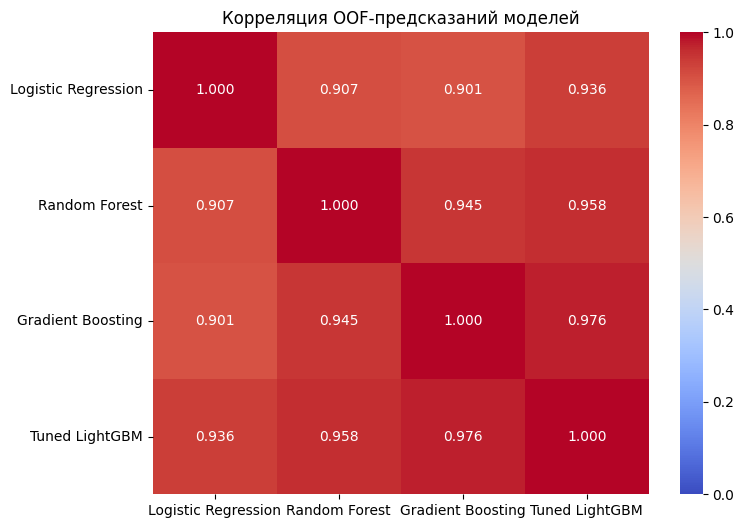

In [82]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    oof_correlation,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=0,
    vmax=1
)

plt.title("Корреляция OOF-предсказаний моделей")
plt.show()

### Корреляция предсказаний

Предсказания моделей достаточно сильно коррелируют между собой.
Наиболее высокая корреляция наблюдается между Gradient Boosting
и LightGBM.

Это объясняется тем, что обе модели используют градиентный бустинг
над деревьями. Высокая корреляция может ограничивать прирост
от ансамблирования, поскольку модели часто совершают одинаковые ошибки.

In [83]:
simple_blend_all_probabilities = (
    oof_logreg
    + oof_random_forest
    + oof_gradient_boosting
    + oof_lightgbm
) / 4

simple_blend_all_predictions = (
    simple_blend_all_probabilities >= 0.5
).astype(int)

simple_blend_all_accuracy = accuracy_score(
    y,
    simple_blend_all_predictions
)

print(
    "Accuracy простого blending всех моделей:",
    round(simple_blend_all_accuracy, 4)
)

Accuracy простого blending всех моделей: 0.8078


In [84]:
simple_blend_top3_probabilities = (
    oof_random_forest
    + oof_gradient_boosting
    + oof_lightgbm
) / 3

simple_blend_top3_predictions = (
    simple_blend_top3_probabilities >= 0.5
).astype(int)

simple_blend_top3_accuracy = accuracy_score(
    y,
    simple_blend_top3_predictions
)

print(
    "Accuracy blending трёх лучших моделей:",
    round(simple_blend_top3_accuracy, 4)
)

Accuracy blending трёх лучших моделей: 0.8117


In [85]:
weight_candidates = {
    "Равные веса": (
        1 / 3,
        1 / 3,
        1 / 3
    ),
    "0.20 / 0.30 / 0.50": (
        0.20,
        0.30,
        0.50
    ),
    "0.20 / 0.40 / 0.40": (
        0.20,
        0.40,
        0.40
    ),
    "0.10 / 0.30 / 0.60": (
        0.10,
        0.30,
        0.60
    ),
    "0.30 / 0.30 / 0.40": (
        0.30,
        0.30,
        0.40
    ),
    "0.25 / 0.35 / 0.40": (
        0.25,
        0.35,
        0.40
    )
}

In [86]:
blending_results = []

for name, weights in weight_candidates.items():
    rf_weight, gb_weight, lgbm_weight = weights

    blend_probabilities = (
        rf_weight * oof_random_forest
        + gb_weight * oof_gradient_boosting
        + lgbm_weight * oof_lightgbm
    )

    blend_predictions = (
        blend_probabilities >= 0.5
    ).astype(int)

    blend_accuracy = accuracy_score(
        y,
        blend_predictions
    )

    blending_results.append({
        "Вариант": name,
        "Вес Random Forest": rf_weight,
        "Вес Gradient Boosting": gb_weight,
        "Вес LightGBM": lgbm_weight,
        "OOF Accuracy": blend_accuracy
    })

blending_results = pd.DataFrame(blending_results)

blending_results["OOF Accuracy"] = (
    blending_results["OOF Accuracy"].round(4)
)

blending_results = blending_results.sort_values(
    "OOF Accuracy",
    ascending=False
).reset_index(drop=True)

blending_results

,Вариант,Вес Random Forest,Вес Gradient Boosting,Вес LightGBM,OOF Accuracy
0,Равные веса,0.333333,0.333333,0.333333,0.8117
1,0.25 / 0.35 / 0.40,0.250000,0.350000,0.400000,0.8105
2,0.20 / 0.30 / 0.50,0.200000,0.300000,0.500000,0.8103
3,0.20 / 0.40 / 0.40,0.200000,0.400000,0.400000,0.8103
4,0.30 / 0.30 / 0.40,0.300000,0.300000,0.400000,0.8102
5,0.10 / 0.30 / 0.60,0.100000,0.300000,0.600000,0.8098


In [87]:
final_cv_comparison = pd.DataFrame({
    "Модель или ансамбль": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting",
        "Tuned LightGBM",
        "Простой blend всех 4 моделей",
        "Простой blend 3 лучших моделей"
    ],
    "OOF Accuracy": [
        accuracy_score(
            y,
            (oof_logreg >= 0.5).astype(int)
        ),
        accuracy_score(
            y,
            (oof_random_forest >= 0.5).astype(int)
        ),
        accuracy_score(
            y,
            (oof_gradient_boosting >= 0.5).astype(int)
        ),
        accuracy_score(
            y,
            (oof_lightgbm >= 0.5).astype(int)
        ),
        simple_blend_all_accuracy,
        simple_blend_top3_accuracy
    ]
})

final_cv_comparison["OOF Accuracy"] = (
    final_cv_comparison["OOF Accuracy"].round(4)
)

final_cv_comparison = final_cv_comparison.sort_values(
    "OOF Accuracy",
    ascending=False
).reset_index(drop=True)

final_cv_comparison

,Модель или ансамбль,OOF Accuracy
0,Простой blend 3 лучших моделей,0.8117
1,Tuned LightGBM,0.8098
2,Простой blend всех 4 моделей,0.8078
3,Gradient Boosting,0.8063
4,Random Forest,0.8033
5,Logistic Regression,0.7908


### Результат blending

Сначала было проверено простое усреднение вероятностей всех четырёх
моделей. Оно показало Accuracy около 0.8078, что оказалось хуже
настроенного LightGBM с Accuracy 0.8098.

Причиной ухудшения стала Logistic Regression. Эта модель показывала
наименьшее индивидуальное качество - 0.7908 - и при равном весе
ухудшала итоговое предсказание ансамбля.

После исключения Logistic Regression было выполнено усреднение
трёх лучших моделей:

- Random Forest;
- Gradient Boosting;
- настроенного LightGBM.

Такой ансамбль показал Accuracy около 0.8117 и превзошёл лучший
одиночный LightGBM примерно на 0.0018, или 0.18 процентного пункта.

Дополнительно были проверены несколько вариантов взвешенного blending.
Увеличение веса LightGBM не улучшило результат. Лучшим осталось простое
усреднение трёх моделей с равными весами.

Небольшой прирост объясняется высокой корреляцией предсказаний
Gradient Boosting и LightGBM: модели часто совершают одинаковые ошибки.

В качестве финального решения выбран простой blending трёх лучших
моделей с равными весами.

## 16. Обучение финального решения и создание submission

По результатам out-of-fold валидации лучшим решением стал
простой blending трёх моделей с равными весами:

- Random Forest;
- Gradient Boosting;
- настроенный LightGBM.

OOF Accuracy ансамбля составила 0.8117, что выше результата
лучшей одиночной модели LightGBM - 0.8098.

На финальном этапе каждая модель обучается на всей обучающей
выборке. Затем их вероятности для тестовой выборки усредняются,
а итоговый класс определяется с порогом 0.5.

Дополнительно создаётся отдельный submission настроенного LightGBM,
чтобы сравнить одиночную модель и ансамбль на публичном leaderboard.

In [88]:
test_columns_to_drop = [
    "PassengerId",
    "GroupId",
    "Cabin",
    "Name"
]

X_test_fe = test_fe.drop(
    columns=test_columns_to_drop
).copy()

# Устанавливаем тот же порядок признаков, что и в обучающей выборке
X_test_fe = X_test_fe[X_fe.columns]

print("Размер X_fe:", X_fe.shape)
print("Размер X_test_fe:", X_test_fe.shape)

print(
    "Порядок признаков совпадает:",
    X_fe.columns.equals(X_test_fe.columns)
)

Размер X_fe: (8693, 20)
Размер X_test_fe: (4277, 20)
Порядок признаков совпадает: True


In [89]:
assert X_fe.columns.equals(X_test_fe.columns)
assert len(X_test_fe) == len(test)
assert len(X_test_fe) == len(sample_submission)

print("Обучающая и тестовая матрицы согласованы")

Обучающая и тестовая матрицы согласованы


In [90]:
from sklearn.base import clone

In [91]:
final_random_forest = clone(
    random_forest_model
)

final_gradient_boosting = clone(
    gradient_boosting_model
)

final_lightgbm = clone(
    best_lgbm_model
)

In [93]:
final_random_forest.fit(
    X_fe,
    y
)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age', 'RoomService',
                                                   'FoodCourt', 'ShoppingMall',
                                                   'Spa', 'VRDeck',
                                                   'MissingCount',
                                                   'GroupMemberNumber',
                                                   'GroupSize', 'IsAlone',
                                                   'CabinNumber', 'TotalSpend',
                                                   'HasSpending']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['HomePlanet', 'CryoSleep',
                                                   'Destination', 'VIP',
                                                   'CabinDeck', 'CabinSide',
                                                   'AgeGroup'])])),
                ('model',
                 RandomForestClassifier(max_depth=20, min_samples_leaf=2,
                                        n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [94]:
final_gradient_boosting.fit(
    X_fe,
    y
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age', 'RoomService',
                                                   'FoodCourt', 'ShoppingMall',
                                                   'Spa', 'VRDeck',
                                                   'MissingCount',
                                                   'GroupMemberNumber',
                                                   'GroupSize', 'IsAlone',
                                                   'CabinNumber', 'TotalSpend',
                                                   'HasSpending']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['HomePlanet', 'CryoSleep',
                                                   'Destination', 'VIP',
                                                   'CabinDeck', 'CabinSide',
                                                   'AgeGroup'])])),
                ('model',
                 GradientBoostingClassifier(max_depth=5, n_estimators=200,
                                            random_state=42))])

In [95]:
final_lightgbm.fit(
    X_fe,
    y
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Age', 'RoomService',
                                                   'FoodCourt', 'ShoppingMall',
                                                   'Spa', 'VRDeck',
                                                   'MissingCount',
                                                   'GroupMemberNumber',
                                                   'GroupSize', 'IsAlone',
                                                   'CabinNumber', 'TotalSpend',
                                                   'HasSpending']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['HomePlanet', 'CryoSleep',
                                                   'Destination', 'VIP',
                                                   'CabinDeck', 'CabinSide',
                                                   'AgeGroup'])])),
                ('model',
                 LGBMClassifier(colsample_bytree=0.9, learning_rate=0.03,
                                max_depth=4, n_estimators=400, n_jobs=1,
                                num_leaves=15, random_state=42, verbose=-1))])

In [96]:
test_rf_probabilities = (
    final_random_forest
    .predict_proba(X_test_fe)[:, 1]
)

test_gb_probabilities = (
    final_gradient_boosting
    .predict_proba(X_test_fe)[:, 1]
)

test_lgbm_probabilities = (
    final_lightgbm
    .predict_proba(X_test_fe)[:, 1]
)

In [97]:
print(
    "Random Forest:",
    test_rf_probabilities.shape
)

print(
    "Gradient Boosting:",
    test_gb_probabilities.shape
)

print(
    "LightGBM:",
    test_lgbm_probabilities.shape
)

Random Forest: (4277,)
Gradient Boosting: (4277,)
LightGBM: (4277,)


In [98]:
test_blend_probabilities = (
    test_rf_probabilities
    + test_gb_probabilities
    + test_lgbm_probabilities
) / 3

In [99]:
test_blend_predictions = (
    test_blend_probabilities >= 0.5
)

test_lgbm_predictions = (
    test_lgbm_probabilities >= 0.5
)

In [100]:
prediction_difference = (
    test_blend_predictions
    != test_lgbm_predictions
)

print(
    "Количество различающихся предсказаний:",
    prediction_difference.sum()
)

print(
    "Доля различающихся предсказаний:",
    round(prediction_difference.mean(), 4)
)

Количество различающихся предсказаний: 194
Доля различающихся предсказаний: 0.0454


## 17. Создание файлов submission

Создаются два файла:

1. `submission_lightgbm.csv` - предсказания настроенного LightGBM;
2. `submission.csv` - финальный blending трёх лучших моделей.

Основным решением по результатам кросс-валидации является
`submission.csv`.

In [101]:
submission_lightgbm = sample_submission.copy()

submission_lightgbm["Transported"] = (
    test_lgbm_predictions.astype(bool)
)

submission_lightgbm.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [102]:
submission = sample_submission.copy()

submission["Transported"] = (
    test_blend_predictions.astype(bool)
)

submission.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [103]:
print("Размер submission:", submission.shape)

print("\nПропуски:")
print(submission.isna().sum())

print("\nРаспределение предсказаний:")
print(submission["Transported"].value_counts())

print("\nТип Transported:")
print(submission["Transported"].dtype)

Размер submission: (4277, 2)

Пропуски:
PassengerId    0
Transported    0
dtype: int64

Распределение предсказаний:
Transported
True     2161
False    2116
Name: count, dtype: int64

Тип Transported:
bool


In [104]:
assert submission.shape == sample_submission.shape

assert submission.columns.tolist() == [
    "PassengerId",
    "Transported"
]

assert submission["PassengerId"].equals(
    test["PassengerId"]
)

assert submission["Transported"].isna().sum() == 0

assert submission["Transported"].dtype == bool

print("Финальный submission прошёл все проверки")

Финальный submission прошёл все проверки


In [105]:
assert submission_lightgbm.shape == sample_submission.shape

assert submission_lightgbm["PassengerId"].equals(
    test["PassengerId"]
)

assert submission_lightgbm["Transported"].isna().sum() == 0

print("Submission LightGBM прошёл все проверки")

Submission LightGBM прошёл все проверки


In [106]:
submission.to_csv(
    "/kaggle/working/submission.csv",
    index=False
)

submission_lightgbm.to_csv(
    "/kaggle/working/submission_lightgbm.csv",
    index=False
)

print("Созданы файлы:")
print("/kaggle/working/submission.csv")
print("/kaggle/working/submission_lightgbm.csv")

Созданы файлы:
/kaggle/working/submission.csv
/kaggle/working/submission_lightgbm.csv


In [107]:
submission_check = pd.read_csv(
    "/kaggle/working/submission.csv"
)

submission_check.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [108]:
print(submission_check.shape)
print(submission_check.dtypes)
print(submission_check.isna().sum())

(4277, 2)
PassengerId    object
Transported      bool
dtype: object
PassengerId    0
Transported    0
dtype: int64
